## Imports + configuration

In [ ]:
%pip install tqdm

In [2]:
import os
import glob
import math
import random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split

In [3]:
# ============================================================
# Configuration
# ============================================================

DATASET_DIR = "dataset"

IMAGE_SIZE = 64

BATCH_SIZE = 32
NUM_EPOCHS = 50

LEARNING_RATE = 2e-4

TIMESTEPS = 1000

LATENT_CHANNELS = 16

BASE_CHANNELS = 64

TRAIN_RATIO = 0.9

NUM_WORKERS = 0

SEED = 42

CHECKPOINT_DIR = "checkpoints_cnn_baseline"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [5]:
# ============================================================
# Reproducibility
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

## Dataset loader

In [6]:
class MazePathDataset(Dataset):

    def __init__(self, dataset_dir):

        self.files = sorted(
            glob.glob(
                os.path.join(
                    dataset_dir,
                    "pair_*.npz"
                )
            )
        )

        if len(self.files) == 0:
            raise RuntimeError(
                f"No .npz files found in {dataset_dir}"
            )

        print(
            f"Found {len(self.files)} samples."
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        data = np.load(
            self.files[idx]
        )

        grid_map = data["map"].astype(
            np.float32
        )

        path = data["path"].astype(
            np.float32
        )

        grid_map = torch.from_numpy(
            grid_map
        )

        path = torch.from_numpy(
            path
        )

        # ----------------------------------------
        # Diffusion target:
        # convert path from {0,1} → {-1,1}
        # ----------------------------------------

        path = path * 2.0 - 1.0

        return {
            "map": grid_map,
            "path": path
        }

## Train / validation split

In [7]:
dataset = MazePathDataset(
    DATASET_DIR
)

train_size = int(
    len(dataset) * TRAIN_RATIO
)

val_size = (
    len(dataset) - train_size
)

generator = torch.Generator().manual_seed(
    SEED
)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

Found 5000 samples.
Train: 4500
Validation: 500


In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

## CNN Encoder

In [ ]:
class CNNMapEncoder(nn.Module):

    def __init__(
        self,
        latent_channels=16
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(
                3,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                16,
                latent_channels,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, grid):

        latent = self.encoder(
            grid
        )

        return latent

## Diffusion timestep embedding

In [11]:
class SinusoidalTimeEmbedding(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.dim = dim

    def forward(self, time):

        device = time.device

        half_dim = self.dim // 2

        embeddings = math.log(
            10000
        ) / (half_dim - 1)

        embeddings = torch.exp(
            torch.arange(
                half_dim,
                device=device
            )
            * -embeddings
        )

        embeddings = (
            time[:, None].float()
            *
            embeddings[None, :]
        )

        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=1
        )

        return embeddings

## UNet Residual Block

In [12]:
class ResBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(
            8,
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.time_mlp = nn.Linear(
            time_dim,
            out_channels
        )

        if in_channels != out_channels:

            self.residual = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.residual = nn.Identity()

    def forward(
        self,
        x,
        time_emb
    ):

        residual = self.residual(x)

        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        # --------------------------------
        # timestep information
        # --------------------------------

        time_feature = self.time_mlp(
            time_emb
        )

        time_feature = time_feature[
            :,
            :,
            None,
            None
        ]

        h = h + time_feature

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + residual

## Conditional UNet

In [13]:
class ConditionalUNet(nn.Module):

    def __init__(
        self,
        map_latent_channels=16,
        base_channels=64,
        time_dim=256
    ):

        super().__init__()

        input_channels = (
            1 + map_latent_channels
        )

        # ========================================
        # Time embedding
        # ========================================

        self.time_embedding = nn.Sequential(

            SinusoidalTimeEmbedding(
                time_dim
            ),

            nn.Linear(
                time_dim,
                time_dim
            ),

            nn.SiLU(),

            nn.Linear(
                time_dim,
                time_dim
            )
        )

        # ========================================
        # Input
        # ========================================

        self.input_conv = nn.Conv2d(
            input_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        # ========================================
        # Encoder
        # ========================================

        self.down1 = ResBlock(
            base_channels,
            base_channels,
            time_dim
        )

        self.pool1 = nn.Conv2d(
            base_channels,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.down2 = ResBlock(
            base_channels,
            base_channels * 2,
            time_dim
        )

        self.pool2 = nn.Conv2d(
            base_channels * 2,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        # ========================================
        # Bottleneck
        # ========================================

        self.mid1 = ResBlock(
            base_channels * 2,
            base_channels * 4,
            time_dim
        )

        self.mid2 = ResBlock(
            base_channels * 4,
            base_channels * 4,
            time_dim
        )

        # ========================================
        # Decoder
        # ========================================

        self.up2 = nn.ConvTranspose2d(
            base_channels * 4,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_block2 = ResBlock(
            base_channels * 4,
            base_channels * 2,
            time_dim
        )

        self.up1 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_block1 = ResBlock(
            base_channels * 2,
            base_channels,
            time_dim
        )

        # ========================================
        # Output
        # ========================================

        self.output = nn.Conv2d(
            base_channels,
            1,
            kernel_size=1
        )

    def forward(
        self,
        x,
        timestep
    ):

        # timestep embedding
        t = self.time_embedding(
            timestep
        )

        # input
        x = self.input_conv(x)

        # ----------------------------------------
        # Down
        # ----------------------------------------

        skip1 = self.down1(
            x,
            t
        )

        x = self.pool1(
            skip1
        )

        skip2 = self.down2(
            x,
            t
        )

        x = self.pool2(
            skip2
        )

        # ----------------------------------------
        # Middle
        # ----------------------------------------

        x = self.mid1(
            x,
            t
        )

        x = self.mid2(
            x,
            t
        )

        # ----------------------------------------
        # Up
        # ----------------------------------------

        x = self.up2(x)

        x = torch.cat(
            [x, skip2],
            dim=1
        )

        x = self.up_block2(
            x,
            t
        )

        x = self.up1(x)

        x = torch.cat(
            [x, skip1],
            dim=1
        )

        x = self.up_block1(
            x,
            t
        )

        return self.output(x)

## CNN Baseline Diffusion Model

In [ ]:
class CNNBaselineDiffusionModel(nn.Module):

    def __init__(
        self,
        latent_channels=16,
        base_channels=64
    ):
        super().__init__()

        self.map_encoder = CNNMapEncoder(
            latent_channels=latent_channels
        )

        self.unet = ConditionalUNet(
            map_latent_channels=latent_channels,
            base_channels=base_channels
        )

    def encode_map(
        self,
        grid_map
    ):
        return self.map_encoder(
            grid_map
        )

    def denoise(
        self,
        noisy_path,
        map_latent,
        timestep
    ):

        model_input = torch.cat(
            [
                noisy_path,
                map_latent
            ],
            dim=1
        )

        return self.unet(
            model_input,
            timestep
        )

    def forward(
        self,
        grid_map,
        noisy_path,
        timestep
    ):

        map_latent = self.encode_map(
            grid_map
        )

        predicted_noise = self.denoise(
            noisy_path,
            map_latent,
            timestep
        )

        return predicted_noise

## DDPM noise schedule

In [15]:
class GaussianDiffusion:

    def __init__(
        self,
        timesteps=1000,
        beta_start=1e-4,
        beta_end=0.02,
        device="cuda"
    ):

        self.timesteps = timesteps
        self.device = device

        # ----------------------------------------
        # Linear beta schedule
        # ----------------------------------------

        self.betas = torch.linspace(
            beta_start,
            beta_end,
            timesteps,
            device=device
        )

        self.alphas = (
            1.0 - self.betas
        )

        self.alpha_cumprod = torch.cumprod(
            self.alphas,
            dim=0
        )

        self.alpha_cumprod_prev = F.pad(
            self.alpha_cumprod[:-1],
            (1, 0),
            value=1.0
        )

        self.sqrt_alpha_cumprod = (
            torch.sqrt(
                self.alpha_cumprod
            )
        )

        self.sqrt_one_minus_alpha_cumprod = (
            torch.sqrt(
                1.0
                -
                self.alpha_cumprod
            )
        )

        self.sqrt_recip_alphas = (
            torch.sqrt(
                1.0 / self.alphas
            )
        )

        # ----------------------------------------
        # Posterior variance
        # ----------------------------------------

        self.posterior_variance = (
            self.betas
            *
            (
                1.0
                -
                self.alpha_cumprod_prev
            )
            /
            (
                1.0
                -
                self.alpha_cumprod
            )
        )

## Helper

In [16]:
def extract(
    values,
    timestep,
    x_shape
):

    batch_size = timestep.shape[0]

    out = values.gather(
        0,
        timestep
    )

    return out.reshape(
        batch_size,
        *((1,) * (len(x_shape) - 1))
    )

## Forward diffusion

In [17]:
def q_sample(
    diffusion,
    x_start,
    timestep,
    noise=None
):

    if noise is None:
        noise = torch.randn_like(
            x_start
        )

    sqrt_alpha_cumprod_t = extract(
        diffusion.sqrt_alpha_cumprod,
        timestep,
        x_start.shape
    )

    sqrt_one_minus_alpha_cumprod_t = (
        extract(
            diffusion.sqrt_one_minus_alpha_cumprod,
            timestep,
            x_start.shape
        )
    )

    noisy_path = (
        sqrt_alpha_cumprod_t
        *
        x_start

        +

        sqrt_one_minus_alpha_cumprod_t
        *
        noise
    )

    return noisy_path, noise

## Initialize model

In [18]:
model = CNNBaselineDiffusionModel(
    latent_channels=LATENT_CHANNELS,
    base_channels=BASE_CHANNELS
).to(DEVICE)

In [19]:
diffusion = GaussianDiffusion(
    timesteps=TIMESTEPS,
    device=DEVICE
)

In [20]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

In [21]:
num_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Trainable parameters: "
    f"{num_parameters:,}"
)

Trainable parameters: 4,358,673


## Shape sanity check

In [22]:
batch = next(
    iter(train_loader)
)

grid_map = batch["map"].to(
    DEVICE
)

path = batch["path"].to(
    DEVICE
)

print(
    "Map:",
    grid_map.shape
)

print(
    "Path:",
    path.shape
)

Map: torch.Size([32, 3, 64, 64])
Path: torch.Size([32, 1, 64, 64])


In [23]:
relational = build_connectivity_channels(
    grid_map
)

print(
    "Relational map:",
    relational.shape
)

Relational map: torch.Size([32, 7, 64, 64])


In [24]:
with torch.no_grad():

    latent = model.encode_map(
        grid_map
    )

print(
    "Cognitive latent:",
    latent.shape
)

Cognitive latent: torch.Size([32, 16, 64, 64])


In [25]:
t = torch.randint(
    0,
    TIMESTEPS,
    (grid_map.shape[0],),
    device=DEVICE
)

noisy_path, true_noise = q_sample(
    diffusion,
    path,
    t
)

print(
    "Noisy path:",
    noisy_path.shape
)

predicted_noise = model(
    grid_map,
    noisy_path,
    t
)

print(
    "Predicted noise:",
    predicted_noise.shape
)

Noisy path: torch.Size([32, 1, 64, 64])
Predicted noise: torch.Size([32, 1, 64, 64])


## Training function

In [26]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    diffusion,
    device
):

    model.train()

    total_loss = 0.0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch in progress_bar:

        grid_map = batch["map"].to(
            device,
            non_blocking=True
        )

        path = batch["path"].to(
            device,
            non_blocking=True
        )

        batch_size = path.shape[0]

        # ----------------------------------------
        # Random timestep for every sample
        # ----------------------------------------

        timestep = torch.randint(
            0,
            diffusion.timesteps,
            (batch_size,),
            device=device
        ).long()

        # ----------------------------------------
        # Forward diffusion
        # ----------------------------------------

        noisy_path, true_noise = q_sample(
            diffusion,
            path,
            timestep
        )

        # ----------------------------------------
        # Predict noise
        # ----------------------------------------

        predicted_noise = model(
            grid_map,
            noisy_path,
            timestep
        )

        # ----------------------------------------
        # DDPM noise prediction loss
        # ----------------------------------------

        loss = F.mse_loss(
            predicted_noise,
            true_noise
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return (
        total_loss
        /
        len(loader)
    )

## Validation function

In [27]:
@torch.no_grad()
def validate(
    model,
    loader,
    diffusion,
    device
):

    model.eval()

    total_loss = 0.0

    for batch in loader:

        grid_map = batch["map"].to(
            device,
            non_blocking=True
        )

        path = batch["path"].to(
            device,
            non_blocking=True
        )

        batch_size = path.shape[0]

        timestep = torch.randint(
            0,
            diffusion.timesteps,
            (batch_size,),
            device=device
        ).long()

        noisy_path, true_noise = q_sample(
            diffusion,
            path,
            timestep
        )

        predicted_noise = model(
            grid_map,
            noisy_path,
            timestep
        )

        loss = F.mse_loss(
            predicted_noise,
            true_noise
        )

        total_loss += loss.item()

    return (
        total_loss
        /
        len(loader)
    )

## Full training loop

In [28]:
best_val_loss = float("inf")

train_losses = []
val_losses = []


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    print(
        f"\nEpoch "
        f"{epoch}/{NUM_EPOCHS}"
    )

    # ========================================
    # Training
    # ========================================

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        diffusion,
        DEVICE
    )

    # ========================================
    # Validation
    # ========================================

    val_loss = validate(
        model,
        val_loader,
        diffusion,
        DEVICE
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    print(
        f"Train loss: "
        f"{train_loss:.6f}"
    )

    print(
        f"Val loss:   "
        f"{val_loss:.6f}"
    )

    # ========================================
    # Save latest
    # ========================================

    checkpoint = {

        "epoch":
            epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "train_loss":
            train_loss,

        "val_loss":
            val_loss,

        "config": {

            "timesteps":
                TIMESTEPS,

            "latent_channels":
                LATENT_CHANNELS,

            "base_channels":
                BASE_CHANNELS
        }
    }

    torch.save(
        checkpoint,
        os.path.join(
            CHECKPOINT_DIR,
            "latest.pt"
        )
    )

    # ========================================
    # Save best
    # ========================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            checkpoint,
            os.path.join(
                CHECKPOINT_DIR,
                "best.pt"
            )
        )

        print(
            "Saved new best model."
        )


Epoch 1/50


Train loss: 0.066801
Val loss:   0.019386
Saved new best model.

Epoch 2/50


Train loss: 0.015903
Val loss:   0.014537
Saved new best model.

Epoch 3/50


Train loss: 0.012590
Val loss:   0.011940
Saved new best model.

Epoch 4/50


Train loss: 0.008950
Val loss:   0.007875
Saved new best model.

Epoch 5/50


...

Train loss: 0.001244
Val loss:   0.001141
Saved new best model.

Epoch 47/50


Train loss: 0.001652
Val loss:   0.001432

Epoch 48/50


Train loss: 0.001528
Val loss:   0.001502

Epoch 49/50


Train loss: 0.001750
Val loss:   0.001528

Epoch 50/50


Train loss: 0.001344
Val loss:   0.001150


## Plot loss curve

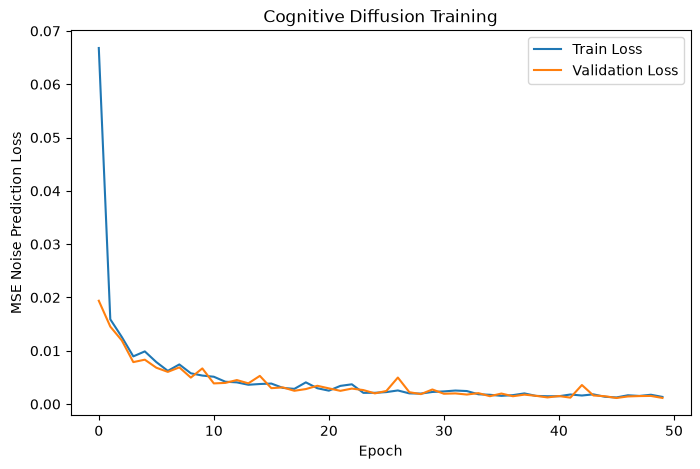

In [29]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Noise Prediction Loss"
)

plt.title(
    "Cognitive Diffusion Training"
)

plt.legend()

plt.show()

## Reverse diffusion / inference

In [30]:
@torch.no_grad()
def p_sample(
    model,
    diffusion,
    x,
    map_latent,
    timestep,
    timestep_index
):

    beta_t = extract(
        diffusion.betas,
        timestep,
        x.shape
    )

    sqrt_one_minus_alpha_cumprod_t = (
        extract(
            diffusion.sqrt_one_minus_alpha_cumprod,
            timestep,
            x.shape
        )
    )

    sqrt_recip_alpha_t = extract(
        diffusion.sqrt_recip_alphas,
        timestep,
        x.shape
    )

    # ----------------------------------------
    # Predict noise
    # ----------------------------------------

    predicted_noise = model.denoise(
        x,
        map_latent,
        timestep
    )

    # ----------------------------------------
    # DDPM posterior mean
    # ----------------------------------------

    model_mean = (
        sqrt_recip_alpha_t
        *
        (
            x

            -

            beta_t
            *
            predicted_noise
            /
            sqrt_one_minus_alpha_cumprod_t
        )
    )

    if timestep_index == 0:

        return model_mean

    posterior_variance_t = extract(
        diffusion.posterior_variance,
        timestep,
        x.shape
    )

    noise = torch.randn_like(
        x
    )

    return (
        model_mean
        +
        torch.sqrt(
            posterior_variance_t
        )
        *
        noise
    )

In [31]:
@torch.no_grad()
def sample_path(
    model,
    diffusion,
    grid_map,
    device
):

    model.eval()

    grid_map = grid_map.to(
        device
    )

    if grid_map.dim() == 3:
        grid_map = grid_map.unsqueeze(0)

    batch_size = grid_map.shape[0]

    # ========================================
    # Encode map ONCE
    # ========================================

    map_latent = model.encode_map(
        grid_map
    )

    # ========================================
    # Start from pure Gaussian noise
    # ========================================

    x = torch.randn(
        batch_size,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=device
    )

    # ========================================
    # Reverse diffusion
    # ========================================

    for i in tqdm(
        reversed(
            range(
                diffusion.timesteps
            )
        ),
        total=diffusion.timesteps,
        desc="Sampling"
    ):

        timestep = torch.full(
            (batch_size,),
            i,
            device=device,
            dtype=torch.long
        )

        x = p_sample(
            model,
            diffusion,
            x,
            map_latent,
            timestep,
            i
        )

    # ========================================
    # [-1,1] → [0,1]
    # ========================================

    x = (
        x + 1.0
    ) / 2.0

    x = torch.clamp(
        x,
        0.0,
        1.0
    )

    return x

## Load best model

In [32]:
checkpoint = torch.load(
    os.path.join(
        CHECKPOINT_DIR,
        "best.pt"
    ),
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model.eval()

print(
    "Loaded epoch:",
    checkpoint["epoch"]
)

print(
    "Validation loss:",
    checkpoint["val_loss"]
)

Loaded epoch: 46
Validation loss: 0.0011406140365579631


/tmp/ipykernel_3390/221025179.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


## Predict on validation sample

In [33]:
import matplotlib.pyplot as plt
import numpy as np


@torch.no_grad()
def visualize_samples(
    model,
    diffusion,
    dataset,
    indices,
    device
):
    """
    Visualize multiple validation samples.

    Each row:
        Input Map | A* Ground Truth | Diffusion Prediction
    """

    num_samples = len(indices)

    fig, axes = plt.subplots(
        num_samples,
        3,
        figsize=(15, 5 * num_samples)
    )

    # If only one sample is requested,
    # make axes 2D for consistent indexing
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):

        # ========================================
        # Load sample
        # ========================================

        sample = dataset[idx]

        grid_map = sample["map"]
        ground_truth = sample["path"]

        # [-1, 1] -> [0, 1]
        ground_truth_01 = (
            ground_truth + 1.0
        ) / 2.0

        # ========================================
        # Diffusion inference
        # ========================================

        predicted_path = sample_path(
            model,
            diffusion,
            grid_map,
            device
        )

        # ========================================
        # Extract map channels
        # ========================================

        obstacle = grid_map[0].cpu().numpy()
        start_map = grid_map[1].cpu().numpy()
        goal_map = grid_map[2].cpu().numpy()

        gt = ground_truth_01[0].cpu().numpy()

        pred = (
            predicted_path[0, 0]
            .cpu()
            .numpy()
        )

        binary_pred = pred > 0.5

        # ========================================
        # Start / goal coordinates
        # ========================================

        start_y, start_x = np.where(
            start_map > 0.5
        )

        goal_y, goal_x = np.where(
            goal_map > 0.5
        )

        # ========================================
        # Ground-truth coordinates
        # ========================================

        gt_y, gt_x = np.where(
            gt > 0.5
        )

        # ========================================
        # Prediction coordinates
        # ========================================

        pred_y, pred_x = np.where(
            binary_pred
        )

        # ========================================
        # Column 1: Input Map
        # ========================================

        ax = axes[row, 0]

        ax.imshow(
            obstacle,
            cmap="gray_r"
        )

        ax.scatter(
            start_x,
            start_y,
            marker="o",
            s=80,
            label="Start"
        )

        ax.scatter(
            goal_x,
            goal_y,
            marker="*",
            s=120,
            label="Goal"
        )

        ax.set_title(
            f"Sample {idx} — Input Map"
        )

        ax.axis("off")

        if row == 0:
            ax.legend()

        # ========================================
        # Column 2: A* Ground Truth
        # ========================================

        ax = axes[row, 1]

        ax.imshow(
            obstacle,
            cmap="gray_r"
        )

        ax.scatter(
            gt_x,
            gt_y,
            s=8
        )

        ax.scatter(
            start_x,
            start_y,
            marker="o",
            s=80
        )

        ax.scatter(
            goal_x,
            goal_y,
            marker="*",
            s=120
        )

        ax.set_title(
            f"Sample {idx} — A* Ground Truth"
        )

        ax.axis("off")

        # ========================================
        # Column 3: Diffusion Prediction
        # ========================================

        ax = axes[row, 2]

        ax.imshow(
            obstacle,
            cmap="gray_r"
        )

        ax.scatter(
            pred_x,
            pred_y,
            s=8
        )

        ax.scatter(
            start_x,
            start_y,
            marker="o",
            s=80
        )

        ax.scatter(
            goal_x,
            goal_y,
            marker="*",
            s=120
        )

        ax.set_title(
            f"Sample {idx} — Diffusion Prediction"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

Sampling: 100%|██████████| 1000/1000 [00:02<00:00, 347.34it/s]


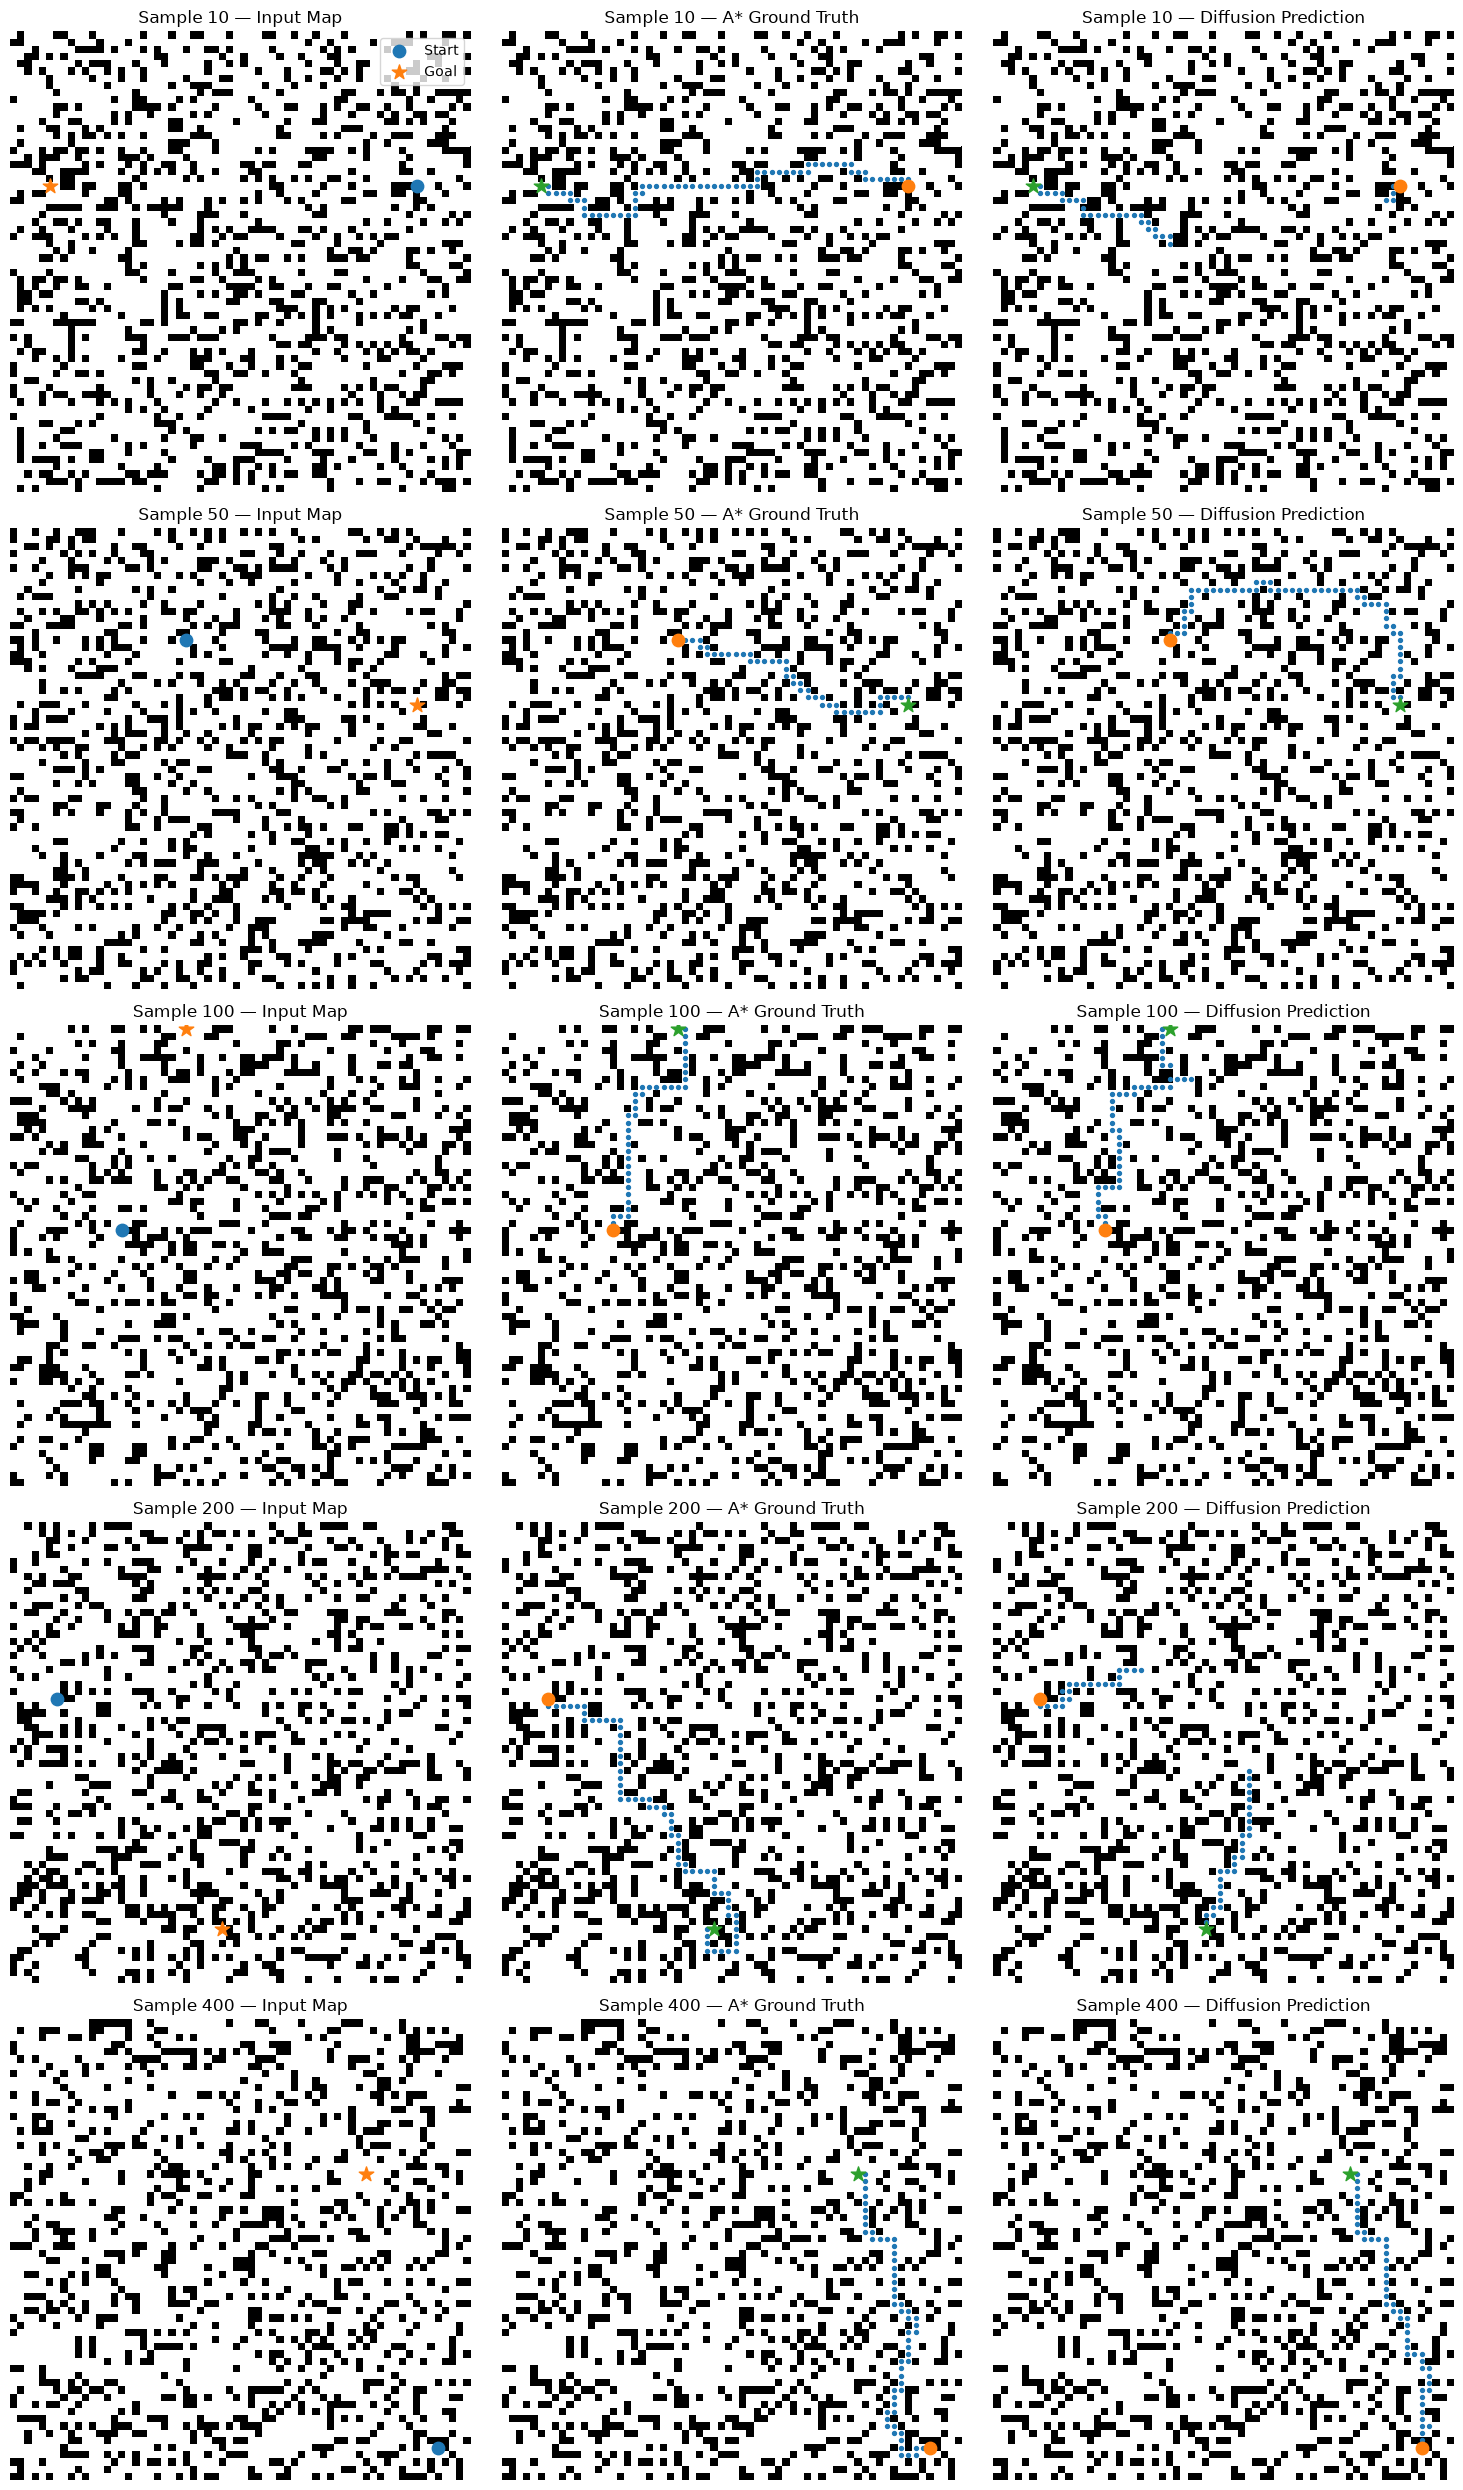

In [34]:
visualize_samples(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    indices=[10, 50, 100, 200, 400],
    device=DEVICE
)

Testing samples: [361, 73, 374, 155, 104, 394, 377, 124, 68, 450]


Sampling: 100%|██████████| 1000/1000 [00:02<00:00, 347.19it/s]


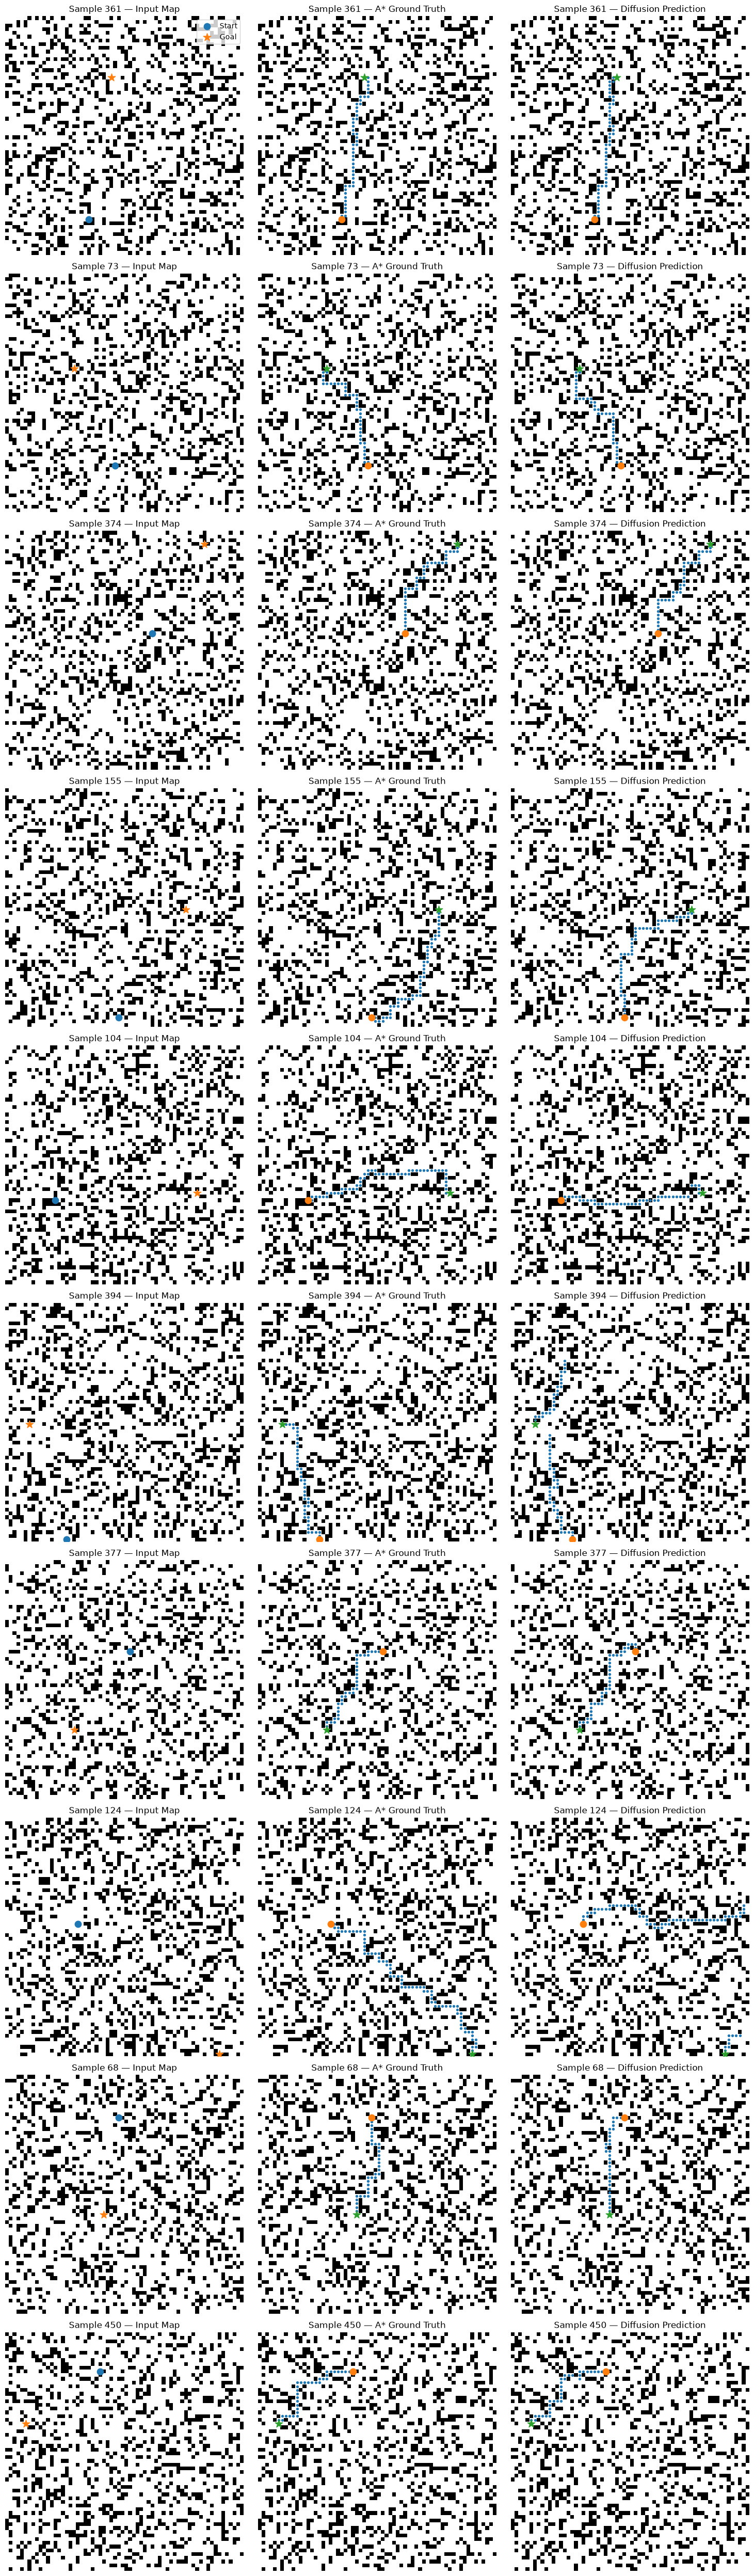

In [35]:
indices = np.random.choice(
    len(val_dataset),
    size=10,
    replace=False
).tolist()

print("Testing samples:", indices)

visualize_samples(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    indices=indices,
    device=DEVICE
)

## Validation evaluator

In [36]:
import numpy as np
import torch
from collections import deque
from tqdm.auto import tqdm

In [37]:
def check_4neighbor_connection(
    binary_path,
    start,
    goal
):
    """
    binary_path: numpy array [H, W], bool
    start: (y, x)
    goal: (y, x)

    Returns:
        True if goal is reachable from start
        using only 4-neighbor path pixels.
    """

    H, W = binary_path.shape

    sy, sx = start
    gy, gx = goal

    # start / goal must both belong to path
    if not binary_path[sy, sx]:
        return False

    if not binary_path[gy, gx]:
        return False

    visited = np.zeros(
        (H, W),
        dtype=bool
    )

    queue = deque()

    queue.append(
        (sy, sx)
    )

    visited[sy, sx] = True

    directions = [
        (-1, 0),   # up
        (1, 0),    # down
        (0, -1),   # left
        (0, 1)     # right
    ]

    while queue:

        y, x = queue.popleft()

        # reached goal
        if (y, x) == (gy, gx):
            return True

        for dy, dx in directions:

            ny = y + dy
            nx = x + dx

            if (
                0 <= ny < H
                and
                0 <= nx < W
            ):

                if (
                    binary_path[ny, nx]
                    and
                    not visited[ny, nx]
                ):

                    visited[ny, nx] = True

                    queue.append(
                        (ny, nx)
                    )

    return False

In [38]:
@torch.no_grad()
def evaluate_single_sample(
    model,
    diffusion,
    sample,
    device,
    threshold=0.5
):
    """
    Evaluate one generated path.

    Returns dictionary with:
        start_in_path
        goal_in_path
        collision_free
        connected
    """

    grid_map = sample["map"]

    # ========================================
    # Generate predicted path
    # ========================================

    predicted_path = sample_path(
        model,
        diffusion,
        grid_map,
        device
    )

    pred = (
        predicted_path[0, 0]
        .cpu()
        .numpy()
    )

    binary_path = (
        pred > threshold
    )

    # ========================================
    # Extract map channels
    # ========================================

    obstacle = (
        grid_map[0]
        .cpu()
        .numpy()
        > 0.5
    )

    start_map = (
        grid_map[1]
        .cpu()
        .numpy()
        > 0.5
    )

    goal_map = (
        grid_map[2]
        .cpu()
        .numpy()
        > 0.5
    )

    # ========================================
    # Find start / goal
    # ========================================

    start_y, start_x = np.where(
        start_map
    )

    goal_y, goal_x = np.where(
        goal_map
    )

    if len(start_y) != 1:
        raise ValueError(
            "Expected exactly one start cell."
        )

    if len(goal_y) != 1:
        raise ValueError(
            "Expected exactly one goal cell."
        )

    start = (
        int(start_y[0]),
        int(start_x[0])
    )

    goal = (
        int(goal_y[0]),
        int(goal_x[0])
    )

    # ========================================
    # Metric 1:
    # Start included?
    # ========================================

    sy, sx = start

    start_in_path = bool(
        binary_path[sy, sx]
    )

    # ========================================
    # Metric 2:
    # Goal included?
    # ========================================

    gy, gx = goal

    goal_in_path = bool(
        binary_path[gy, gx]
    )

    # ========================================
    # Metric 3:
    # Collision free?
    # ========================================

    collision_mask = (
        binary_path
        &
        obstacle
    )

    collision_count = int(
        collision_mask.sum()
    )

    collision_free = (
        collision_count == 0
    )

    # ========================================
    # Metric 4:
    # Connected start -> goal?
    # ========================================

    connected = (
        check_4neighbor_connection(
            binary_path,
            start,
            goal
        )
    )

    return {
        "start_in_path":
            start_in_path,

        "goal_in_path":
            goal_in_path,

        "collision_free":
            collision_free,

        "collision_count":
            collision_count,

        "connected":
            connected
    }

In [39]:
@torch.no_grad()
def evaluate_validation_set(
    model,
    diffusion,
    dataset,
    device,
    num_samples=100,
    threshold=0.5
):
    """
    Evaluate multiple validation samples.
    """

    model.eval()

    num_samples = min(
        num_samples,
        len(dataset)
    )

    results = []

    for idx in tqdm(
        range(num_samples),
        desc="Evaluating"
    ):

        sample = dataset[idx]

        result = evaluate_single_sample(
            model=model,
            diffusion=diffusion,
            sample=sample,
            device=device,
            threshold=threshold
        )

        result["index"] = idx

        results.append(
            result
        )

    return results

In [40]:
results = evaluate_validation_set(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    device=DEVICE,
    num_samples=100,
    threshold=0.5
)

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

In [41]:
def summarize_results(
    results
):

    total = len(results)

    start_rate = sum(
        r["start_in_path"]
        for r in results
    ) / total

    goal_rate = sum(
        r["goal_in_path"]
        for r in results
    ) / total

    collision_free_rate = sum(
        r["collision_free"]
        for r in results
    ) / total

    connected_rate = sum(
        r["connected"]
        for r in results
    ) / total

    avg_collisions = np.mean(
        [
            r["collision_count"]
            for r in results
        ]
    )

    print(
        f"Samples evaluated: {total}"
    )

    print(
        f"Start included:      "
        f"{start_rate * 100:.2f}%"
    )

    print(
        f"Goal included:       "
        f"{goal_rate * 100:.2f}%"
    )

    print(
        f"Collision-free:      "
        f"{collision_free_rate * 100:.2f}%"
    )

    print(
        f"Connected S -> G:    "
        f"{connected_rate * 100:.2f}%"
    )

    print(
        f"Average collisions:  "
        f"{avg_collisions:.2f}"
    )

In [42]:
summarize_results(
    results
)

Samples evaluated: 100
Start included:      96.00%
Goal included:       100.00%
Collision-free:      45.00%
Connected S -> G:    56.00%
Average collisions:  0.94


In [43]:
def compute_success_rate(
    results
):

    successes = []

    for r in results:

        success = (
            r["start_in_path"]
            and
            r["goal_in_path"]
            and
            r["collision_free"]
            and
            r["connected"]
        )

        successes.append(
            success
        )

    success_rate = (
        sum(successes)
        /
        len(successes)
    )

    print(
        f"Valid Path Success:  "
        f"{success_rate * 100:.2f}%"
    )

    return success_rate

In [44]:
success_rate = compute_success_rate(
    results
)

Valid Path Success:  18.00%
